# L5: Image Generation Agent

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [1]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install google-adk

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install google-adk --user --force-reinstall

  Using cached google_adk-2.6.3-py3-none-any.whl.metadata (17 kB)
  Using cached aiohttp-3.14.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached aiosqlite-0.22.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached authlib-1.7.2-py2.py3-none-any.whl.metadata (10 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached fastapi-0.141.1-py3-none-any.whl.metadata (27 kB)
  Using cached google_auth-2.56.3-py3-none-any.whl.metadata (6.0 kB)
  Using cached google_genai-2.17.0-py3-none-any.whl.metadata (56 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached opentelemetry_api-1.42.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached opentelemetry_sdk-1.42.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 k

In [4]:
import json
import random
from google import genai
from google.genai import types
from google.adk.agents import Agent
from google.adk.runners import InMemoryRunner
from typing import List, Dict
from pydantic import BaseModel, Field
from IPython.display import Image, Markdown, display

In [5]:
import os
from helper import authenticate

credentials, project_id = authenticate()
client = genai.Client(
    project=project_id,
    location="global",
    credentials=credentials,
    http_options=types.HttpOptions(
         base_url=os.getenv("GOOGLE_VERTEX_BASE_URL")
    )
)

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download"</em>.</p>
</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different run results:</b> The output generated by AI models, and agents can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

### ⚠️ Compatibility Update — July 2026:

This notebook has been updated to use the current release of the Gemini image model.

**Migration Details**
* Old endpoint: `gemini-3.1-flash-image-preview`
* New endpoint: `gemini-3.1-flash-image`

**What changed:** The preview endpoint has been retired and replaced by the standard release endpoint. All calls in this notebook now target `gemini-3.1-flash-image`.

**What to expect:** No change in behavior — same underlying model, updated endpoint name.

In [6]:
TEXT_MODEL_ID = "gemini-3-flash-preview"
IMAGE_MODEL_ID = "gemini-3.1-flash-image" # updated July 2026

## Tool 1: `brand_analysis`

In [7]:
def brand_analysis(brand_guidelines_image: str):

    class BrandInfo(BaseModel):
        colors: str
        typography: str
        icon_style: str
        brand_voice: str
        ui_elements: str

    image_analysis_prompt = """
    Analyze the attached brand guidelines image and extract a comprehensive 
    Visual Design DNA for a high-fidelity UI mockup.

    Instructions:

    Color Palette: Identify primary, secondary, and accent HEX codes 
    (or detailed descriptions). Note the "vibe" of the colors.

    Typography: Identify font families, weights, and the intended hierarchy.

    Logo & Iconography: Describe the logo's geometry and the required style 
    for icons (e.g., "Thin-line minimalist," "3D Claymorphism," or "Solid 
    glyphs").

    Brand Voice: Define the "personality" of the brand in 5 keywords 
    (e.g., Trustworthy, Disruptive, Playful).

    UI Specifics: Extract any mentions of border-radii (rounded vs. sharp), 
    shadow usage, or spacing patterns.
    """

    with open(brand_guidelines_image, "rb") as f:
        image = f.read()

    response = client.models.generate_content(
        model=TEXT_MODEL_ID,
        contents=[
            types.Part.from_bytes(data=image, mime_type="image/png"),
            image_analysis_prompt,
        ],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=BrandInfo,
        ),
    )
    return json.loads(response.text)

### Tool 1 - Test

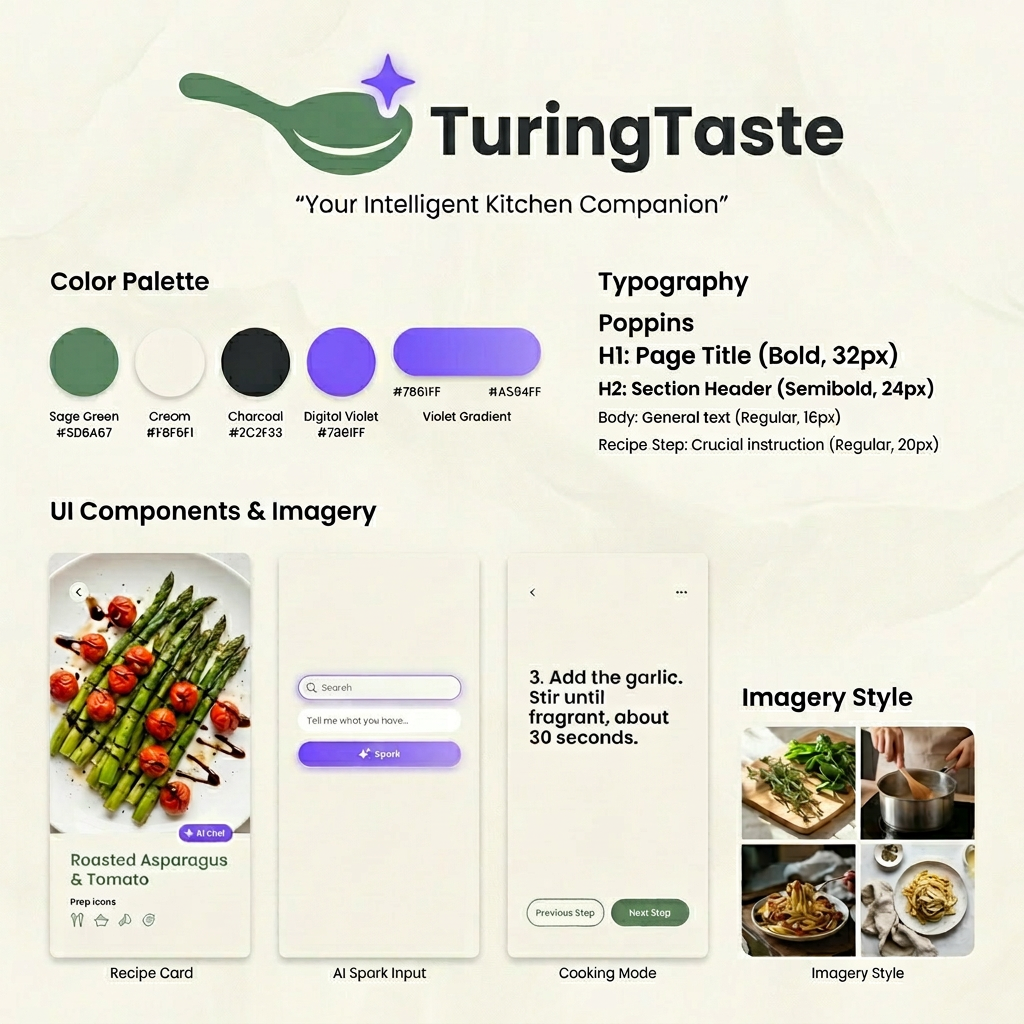

In [8]:
brand_image = "guide.png"
display(Image(brand_image, width=400))

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> The following notebook cell may take a few minutes to run.</p>

In [9]:
analysis = brand_analysis(brand_image)

sections = {
    "Color Palette": "colors",
    "Typography": "typography",
    "Logo & Iconography": "icon_style",
    "Brand Voice": "brand_voice",
    "UI Specifics": "ui_elements"
}

for title, key in sections.items():
    print(f"\n--- {title}: ---")
    display(Markdown(analysis.get(key, "No data found.")))


--- Color Palette: ---


Primary palette includes Sage Green (#5D6A67), Cream (#F8F5F1), and Charcoal (#2C2F33). Accent color is Digital Violet (#7861FF) featuring a gradient (#7861FF to #A584FF). The vibe is natural and organic balanced with a modern, high-tech 'AI' feel.


--- Typography: ---


The brand exclusively uses the Poppins font family. Hierarchy: H1 Page Title (Bold, 32px), H2 Section Header (Semibold, 24px), Body text (Regular, 16px), and Recipe Steps (Regular, 20px) for high legibility.


--- Logo & Iconography: ---


The logo is a stylized spoon combined with a geometric four-pointed spark. UI icons follow a 'thin-line minimalist' style with uniform stroke weights, as seen in the Prep icons section.


--- Brand Voice: ---


Intelligent, Helpful, Modern, Approachable, Sophisticated


--- UI Specifics: ---


Features highly rounded corners (large border-radius) on buttons, input fields, and containers. Uses pill-shaped buttons with gradients, soft subtle drop shadows for depth, and clean, high-contrast imagery with warm tones.

## Tool 2: `generate_design_concepts`

In [10]:
def generate_design_concepts(
        user_description: str, 
        brand_guidelines_image: str, 
        brand_guidelines: str
) -> dict:

    class ConceptInfo(BaseModel):
        title: str
        description: str
        prompt: str

    class Ideas(BaseModel):
        ideas: List[ConceptInfo]

    prompt = f"""
    Based on the following user description and brand guidelines, generate a 
    single comprehensive UI design concept for a web application.

    User Description: {user_description}
    Brand Guidelines (extracted keywords): {brand_guidelines}

    For the concept, provide:
    * Title: A concise and evocative name for the design concept.
    * Design Description: A detailed description of the layout, color 
    palette, typography, and key visual elements, explaining how it aligns 
    with the user's description and brand identity.
    * Nano Banana Prompt: A specific text prompt that can be used with 
    Nano Banana to create a photorealistic or illustrative mockup UI 
    rendering of this concept. Focus on visual details.

    Ensure the concept fulfills all of the user's
    core requirements and maintains brand consistency.
    """

    with open(brand_guidelines_image, "rb") as f:
        image = f.read()

    response = client.models.generate_content(
        model=TEXT_MODEL_ID,
        contents=[
            types.Part.from_bytes(data=image, mime_type="image/png"),
            prompt,
        ],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=Ideas,
        ),
    )

    return json.loads(response.text)

### Tool 2 - Test

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> The following notebook cell may take a few minutes to run.</p>

In [11]:
brief = """
Create a web UI landing page for this cooking app.
"""

ideas = generate_design_concepts(brief, "guide.png", analysis)

for concept in ideas['ideas']:
    print(f"\n--- Concept ---")
    display(Markdown(f"**Title:** {concept['title']}"))
    display(Markdown(f"**Description:** {concept['description']}"))
    display(Markdown(f"**Prompt:** {concept['prompt']}"))


--- Concept ---


**Title:** TuringTaste: The Intelligent Culinary Portal

**Description:** This landing page design utilizes a minimalist 'Cream' (#F8F5F1) canvas to establish a natural, organic feel. The 'Sage Green' (#5D6A67) is used for secondary navigation and utility labels, while the 'Digital Violet' gradient identifies the core AI-driven features, specifically the 'AI Spark' input field in the hero section. The layout features a bold Poppins H1 title, a large pill-shaped search input asking 'Tell me what you have...', and a grid of recipe cards with high-contrast food photography and extreme border-radii. Thin-line minimalist icons are used for 'Prep' information, ensuring a sophisticated, high-tech vibe that remains approachable.

**Prompt:** A professional web UI landing page mockup for a cooking app titled 'TuringTaste'. The design features a clean cream (#F8F5F1) background and bold charcoal (#2C2F33) Poppins typography. In the hero section, there is a prominent, highly-rounded search bar with the placeholder text 'Tell me what you have...' paired with a pill-shaped button featuring a vibrant violet gradient (#7861FF to #A584FF) and a four-pointed star icon. Below the hero is a section of recipe cards with very soft, large rounded corners, displaying high-quality, warm-toned images of roasted asparagus. Thin-line minimalist icons denote prep time and tools. The aesthetic is sophisticated, modern, and clean, with sage green (#5D6A67) accents and subtle drop shadows.

## Tool 3: `generate_idea_image`

In [12]:
def generate_idea_image(prompt: str, brand_guidelines_image: str) -> str:

    prompt = f"""
    Use the following description to generate a UI mockup that adheres 
    to the provided brand guidelines: {prompt}
    """
    with open(brand_guidelines_image, "rb") as f:
        image = f.read()

    response = client.models.generate_content(
        model=IMAGE_MODEL_ID,
        contents=[
            types.Part.from_bytes(
                data=image,
                mime_type="image/png",
            ),
            prompt,
        ],
        config=types.GenerateContentConfig(
            response_modalities=['IMAGE'],
            image_config=types.ImageConfig(
                aspect_ratio="16:9",
                output_mime_type="image/png",
            ),
        ),
    )
    for part in response.candidates[0].content.parts:
        if part.inline_data:
            id = random.randint(1, 10000)
            path = f"{id}_idea.png"
            with open(path, "wb") as f:
                f.write(part.inline_data.data)
            display(Image(data=part.inline_data.data, width=500))
            return path

### Tool 3 - Test

In [13]:
prompt = concept['prompt']
print(prompt)

A professional web UI landing page mockup for a cooking app titled 'TuringTaste'. The design features a clean cream (#F8F5F1) background and bold charcoal (#2C2F33) Poppins typography. In the hero section, there is a prominent, highly-rounded search bar with the placeholder text 'Tell me what you have...' paired with a pill-shaped button featuring a vibrant violet gradient (#7861FF to #A584FF) and a four-pointed star icon. Below the hero is a section of recipe cards with very soft, large rounded corners, displaying high-quality, warm-toned images of roasted asparagus. Thin-line minimalist icons denote prep time and tools. The aesthetic is sophisticated, modern, and clean, with sage green (#5D6A67) accents and subtle drop shadows.


<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> The following notebook cell may take a few minutes to run.</p>

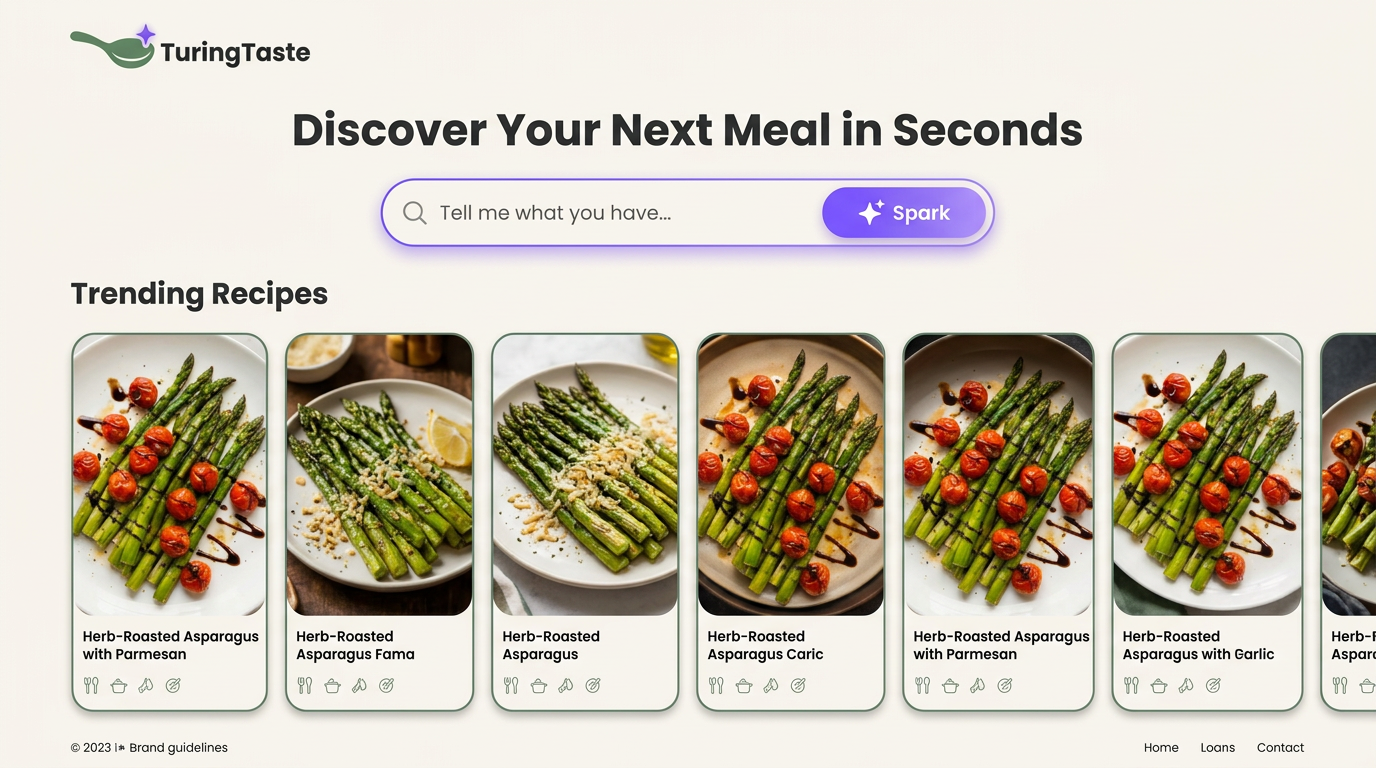

In [14]:
image_idea = generate_idea_image(prompt, "guide.png")
image_path = image_idea

## Tool 4: `evaluate_image`

In [15]:
def evaluate_image(threshold: float, brand_guide: str, ui_image: str) -> dict:
 
    class EvaluationResult(BaseModel):
        scores: Dict[str, float]
        overall: float
        is_passing: bool = Field(alias="pass")
        feedback: str

    eval_prompt = f"""
    Carefully and critically evaluate the attached UI mockup against the 
    original brand guidelines.

    Score each criterion in a range from 1 (poor) to 5 (excellent):
    - visual aesthetic: overall appeal and brand alignment (compare logos, 
    colors, typography and brand elements against the guideline image)
    - contrast: unique elements should stand apart in regards to color, 
    shape, and direction
    - repetition: consistency of components and patterns
    - alignment: grid consistency and horizontal/vertical flow
    - proximity: logical grouping of related elements

    Return ONLY a JSON object:
    - scores: {{criterion_name: score, ...}},
    - overall: average of all scores,
    - is_passing: true if overall >= {threshold},
    - feedback: specific prompt changes to improve if fail, else 'Looks good'

    """
    with open(ui_image, "rb") as f:
        image = f.read()
    with open(brand_guide, "rb") as f:
        guide = f.read()

    response = client.models.generate_content(
        model=TEXT_MODEL_ID,
        contents=[
            types.Part.from_bytes(data=image, mime_type="image/png"),
            types.Part.from_bytes(data=guide, mime_type="image/png"),
            eval_prompt,
        ],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=EvaluationResult,
        ),
    )

    result = json.loads(response.text)
    print(f"Overall: {result['overall']}")
    print(f"Feedback: {result['feedback']}")
    return result

### Tool 4 - Test

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> The following notebook cell may take a few minutes to run.</p>

In [ ]:
results = evaluate_image(4.6, "guide.png", image_path)

print(f"--- Evaluation Result [{'PASS' if results['pass'] else 'FAIL'}] ---")
print(f"Overall Score: {results['overall']}")
for criteria, score in results['scores'].items():
    print(f"- {criteria.title()}: {score}")
print(f"\nFeedback: {results['feedback']}")

## Wiring the Agent

In [ ]:
SYSTEM_PROMPT = """You are a UI design agent. When asked to create a 
mockup UI:

1. Call brand_analysis with the user's style guide image to get an essence 
of the brand. The initial style image is in a local file named guide.png.
2. Call generate_design_concepts to get two distinct mockup UI concepts 
based on the user input and brand guidelines. If the resulting two concepts 
are not distinct generate a new concept until there are two different design 
ideas. Distinct concepts should refer to different themes, UI components, 
layouts, and elements.
3. For each concept:
   a. Call generate_idea_image with the prompt and style guide image. Make 
   sure you remember the image file name for the evaluation step.
   b. Call evaluate_image with a 4.8 threshold, the style guide image and 
   the mockup UI image.
   c. If the evaluation fails (pass=false), use the feedback to adjust the 
   prompt and retry generating the images with a new prompt that 
   incorporates the feedback.
   d. Maximum 1 retry.
4. After an image passes, list the image file path. A total of two images 
should pass.
"""

from google.adk.models import Gemini
class DLAIGemini(Gemini):
    @property
    def api_client(self) -> genai.Client:
        return genai.Client(
            project=project_id,
            location="global",
            credentials=credentials,
            http_options=types.HttpOptions(
                 base_url=os.getenv("GOOGLE_VERTEX_BASE_URL")
            )
        )
        
agent = Agent(
    name="image_agent",
    # model=TEXT_MODEL_ID,
    model=DLAIGemini(model=TEXT_MODEL_ID),
    tools=[
        brand_analysis,
        generate_design_concepts,
        generate_idea_image,
        evaluate_image,
    ],
    instruction=SYSTEM_PROMPT,
)

### Run the agent

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> The following notebook cell may take a few minutes to run.</p>

In [ ]:
runner = InMemoryRunner(agent=agent, app_name="image_agent")
session = await runner.session_service.create_session(
    app_name="image_agent", user_id="user"
)

prompt = """Create a UI landing page for this cooking app. 
The initial style guide image is in a file named guide.png"""

user_message = types.Content(
    role="user",
    parts=[types.Part(text=prompt)]
)
    
async for event in runner.run_async(
    user_id="user",
    session_id=session.id,
    new_message=user_message,
):
    if event.content and event.content.parts:
        for part in event.content.parts:
            if part.text:
                print(part.text)
            if part.function_call:
                print(f"\u2192 Calling: {part.function_call.name}")

**Resources**
- Agent Development Kit (ADK) [documentation](https://adk.dev/)